In [1]:
import pandas as pd
import plotly.express as px
import folium
from IPython.display import display
import matplotlib.pyplot as plt
from folium.plugins import HeatMap
from folium import plugins

In [2]:
# Load the CSV file
file_path = "/Users/yashwanthp/Downloads/indo_ns_loc.csv"  # Replace with the path to your CSV file
df = pd.read_csv(file_path)

In [3]:
# Drop duplicates based on the 'ip' column
unique_ips = df.drop_duplicates(subset="IP")

# Check for necessary columns
if not {"latitude", "longitude", "IP"}.issubset(unique_ips.columns):
    raise ValueError("Ensure your CSV has 'latitude', 'longitude', and 'IP' columns.")

# Filter rows with valid latitude and longitude values
unique_ips = unique_ips[(unique_ips["latitude"].notnull()) & (unique_ips["longitude"].notnull())]

In [4]:
# Create a base map centered on Indonesia
m = folium.Map(location=[-2.5, 118.0], zoom_start=5)

# Add circular markers for unique IPs
for _, row in unique_ips.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,  # Radius of the circle
        color="blue",  # Circle border color
        fill=True,
        fill_color="blue",  # Fill color
        fill_opacity=0.6,  # Opacity of the fill
        popup=f"IP: {row['IP']}"  # Tooltip when clicking the marker
    ).add_to(m)

display(m)

In [14]:
import folium
import pandas as pd

# Sample 30% of the data for red points
red_points = unique_ips.sample(frac=0.1, random_state=42)  # Randomly select 30%
blue_points = unique_ips.drop(red_points.index)  # Remaining points for blue

# Create a base map centered on Indonesia
m = folium.Map(location=[-2.5, 118.0], zoom_start=5)

# Add red circular markers for sampled IPs
for _, row in red_points.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,  # Radius of the circle
        color="red",  # Circle border color
        fill=True,
        fill_color="red",  # Fill color
        fill_opacity=0.6,  # Opacity of the fill
        popup=f"IP: {row['IP']}"  # Tooltip when clicking the marker
    ).add_to(m)

# Add blue circular markers for the rest
# for _, row in blue_points.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,  # Radius of the circle
        color="",  # Circle border color
        fill=True,
        fill_color="",  # Fill color
        fill_opacity=0.6,  # Opacity of the fill
        popup=f"IP: {row['IP']}"  # Tooltip when clicking the marker
    ).add_to(m)

# Display the map
display(m)


In [5]:
# Extract latitude and longitude as a list of lists for HeatMap
heat_data = unique_ips[["latitude", "longitude"]].values.tolist()


# Create a base map centered on Indonesia
m = folium.Map(location=[-2.5, 118.0], zoom_start=5)

# Add HeatMap layer
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(m)

# Save the map as an HTML file
m.save("indonesia_ip_heatmap.html")

display(m)

In [6]:
eq_file_path = "/Users/yashwanthp/Downloads/earthquakes-2024-10-12_16-04-47_-0400.tsv"  # Replace with your CSV file path
volcano_file = "/Users/yashwanthp/Downloads/volcano-events-2024-10-12_16-05-37_-0400.tsv"  # Replace with your file path
tsunami_file = "/Users/yashwanthp/Downloads/tsunamis-2024-10-12_16-03-43_-0400.tsv"  # Replace with your file path

eq_df = pd.read_csv(eq_file_path, delimiter="\t")
volcano_df = pd.read_csv(volcano_file, delimiter="\t")
tsunami_df = pd.read_csv(tsunami_file, delimiter="\t")

In [7]:
# Rename columns to ensure they match the expected ones
eq_df = eq_df.rename(columns={
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Focal Depth (km)': 'focal_depth',
    'Mag': 'magnitude'
})

# Remove rows with NaN values in latitude or longitude
eq_df = eq_df.dropna(subset=['latitude', 'longitude'])
# Ensure necessary columns are available in the data
if not {"latitude", "longitude", "focal_depth", "magnitude"}.issubset(eq_df.columns):
    raise ValueError("Ensure your TSV has 'latitude', 'longitude', 'focal_depth', and 'magnitude' columns.")


volcano_df = volcano_df.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude', 'Name': 'name'})
volcano_df = volcano_df.dropna(subset=['latitude', 'longitude'])

tsunami_df = tsunami_df.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude', 'Earthquake Magnitude': 'earthquake magnitude', 'Location Name': 'location name'})
tsunami_df = tsunami_df.dropna(subset=['latitude', 'longitude'])


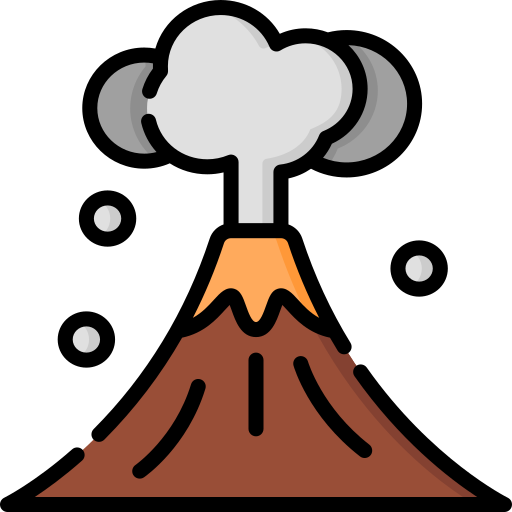
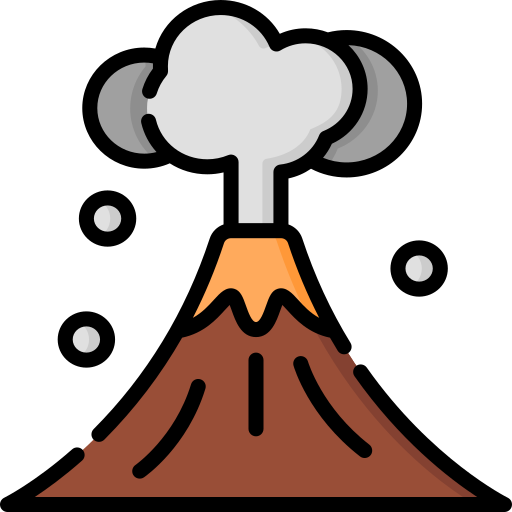
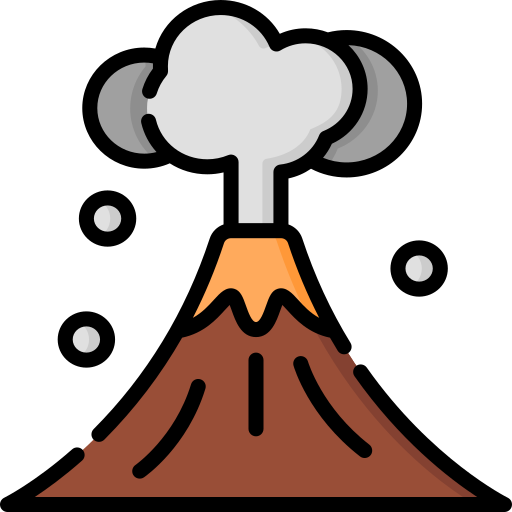
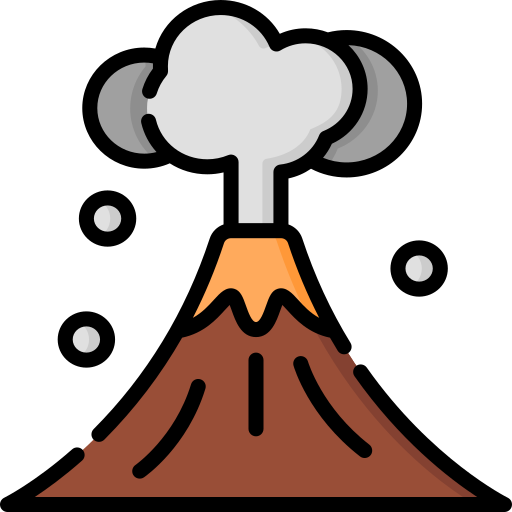
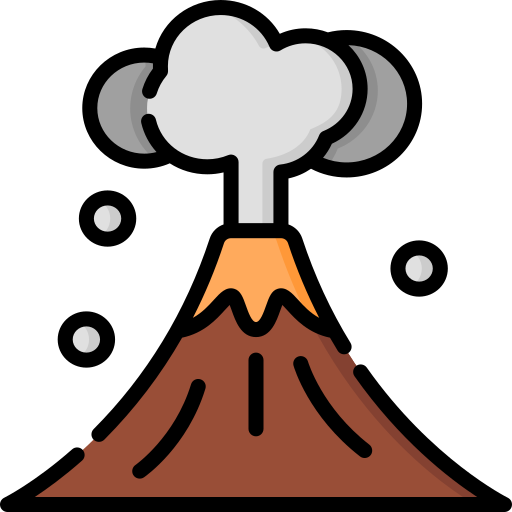
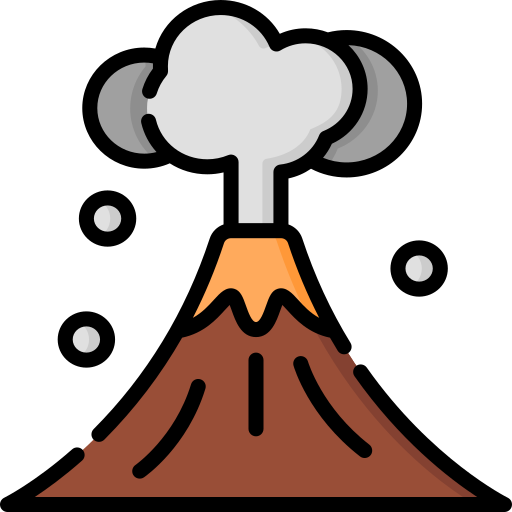
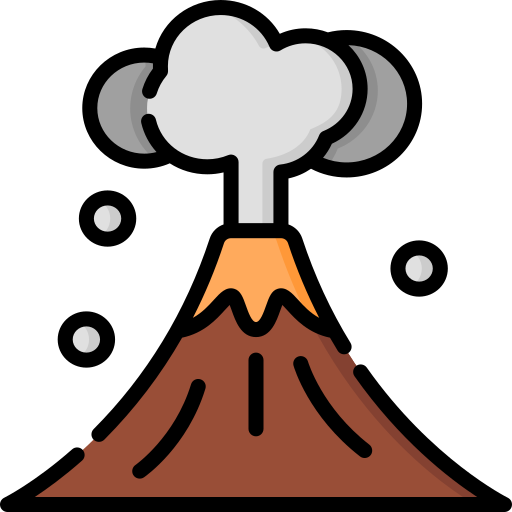
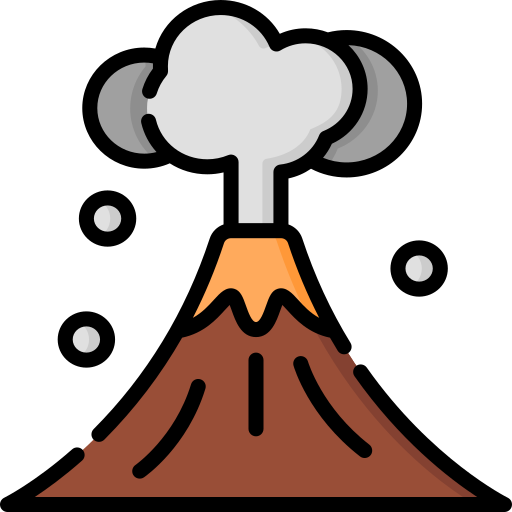
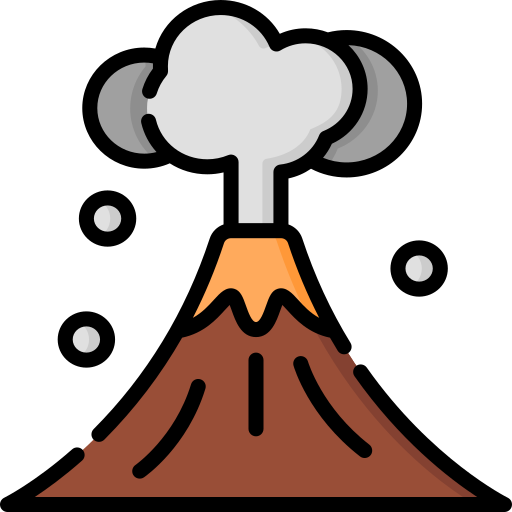
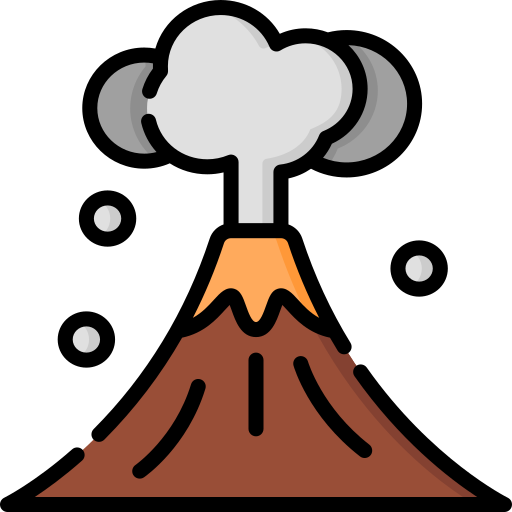
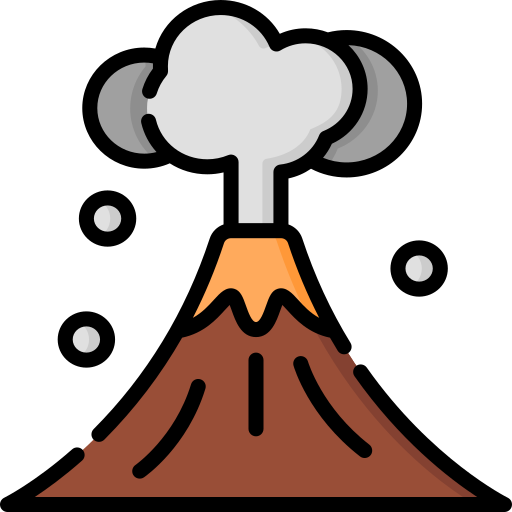
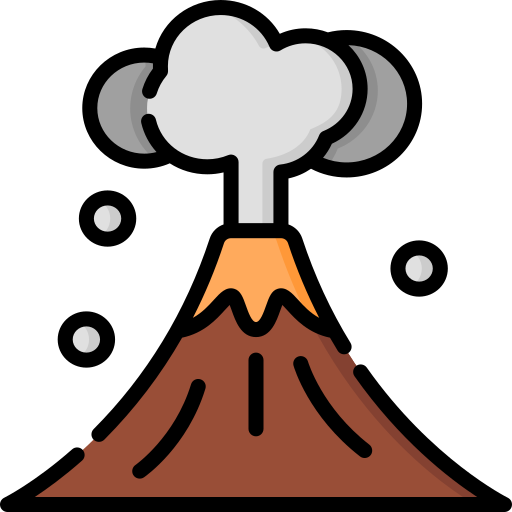
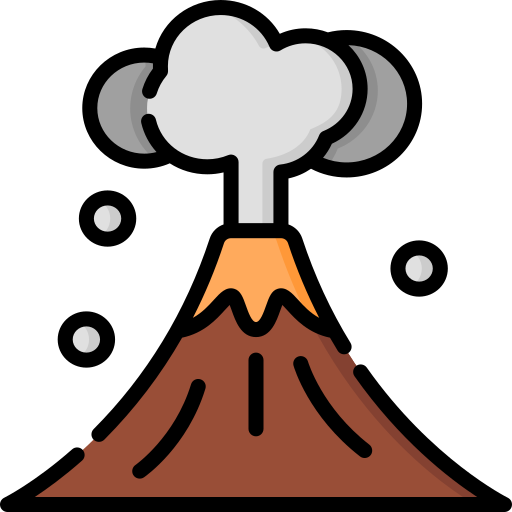
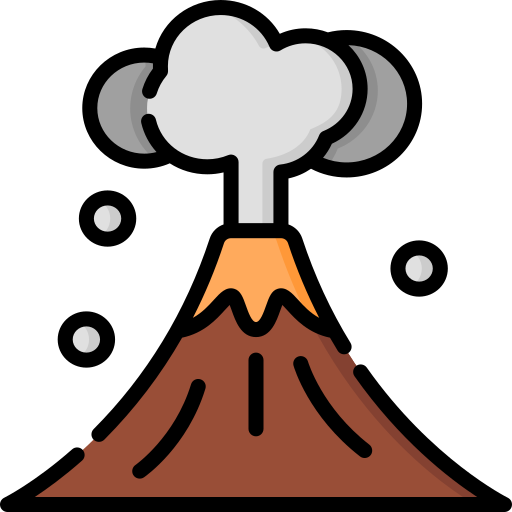
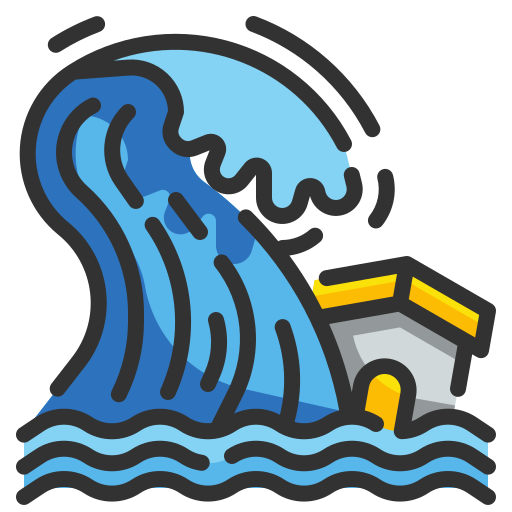
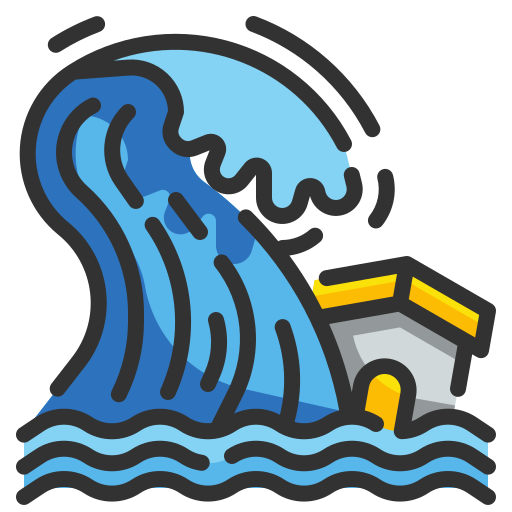
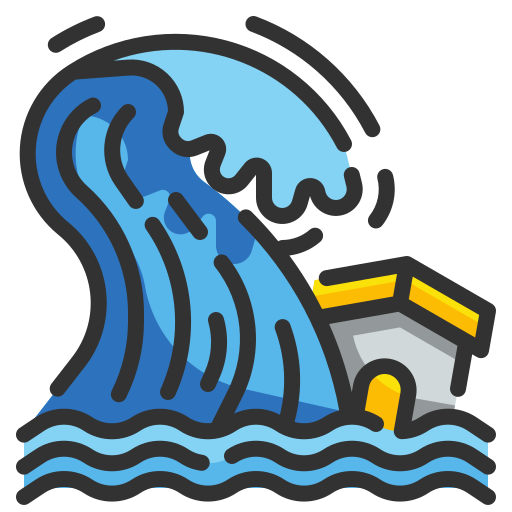
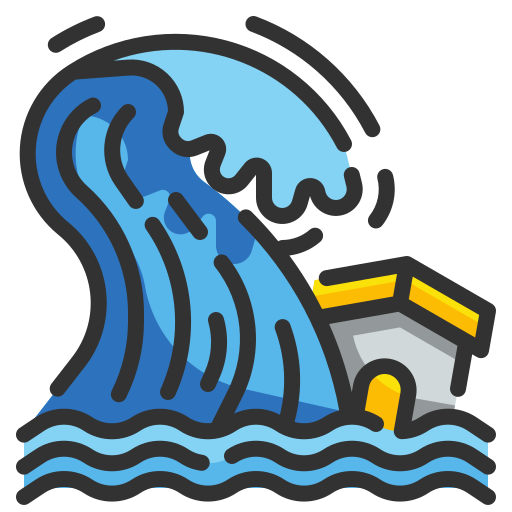
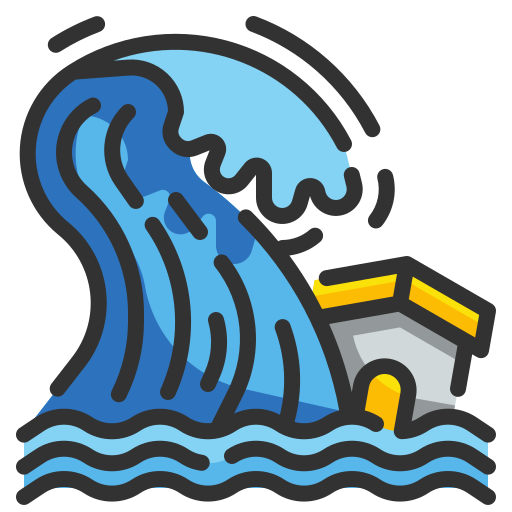
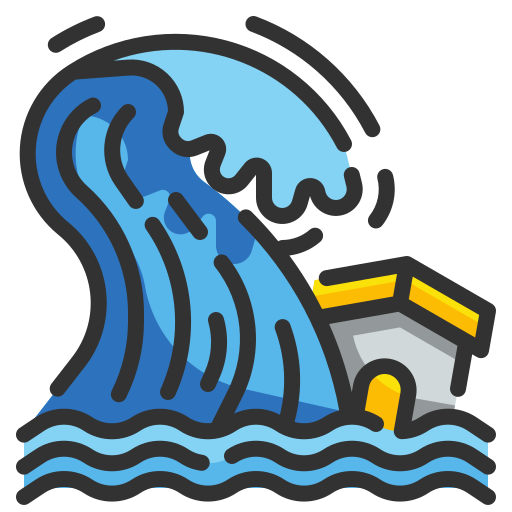
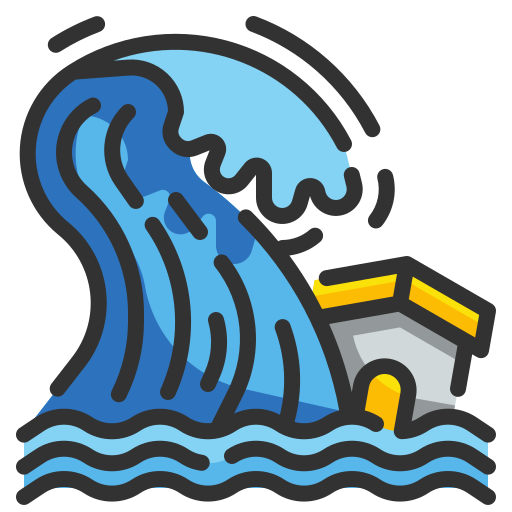
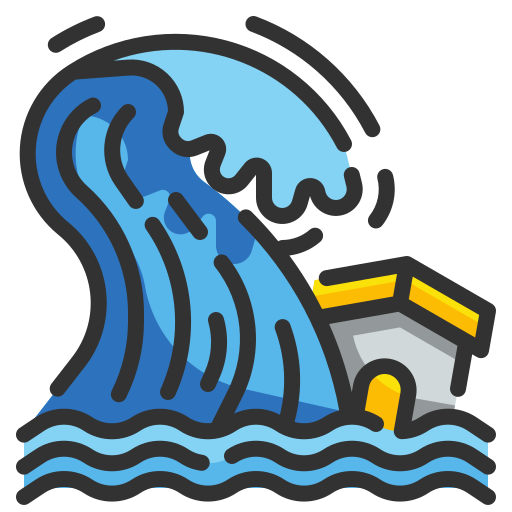
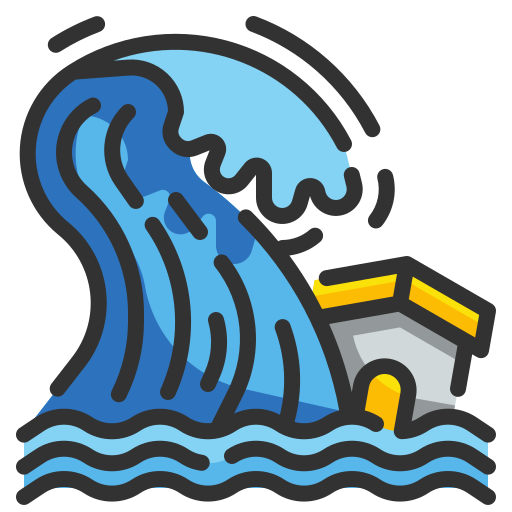
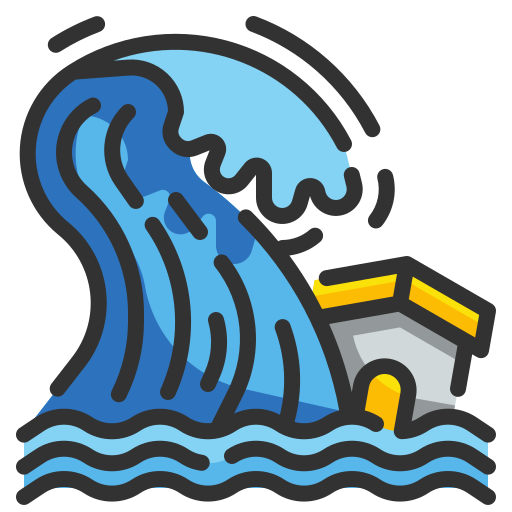
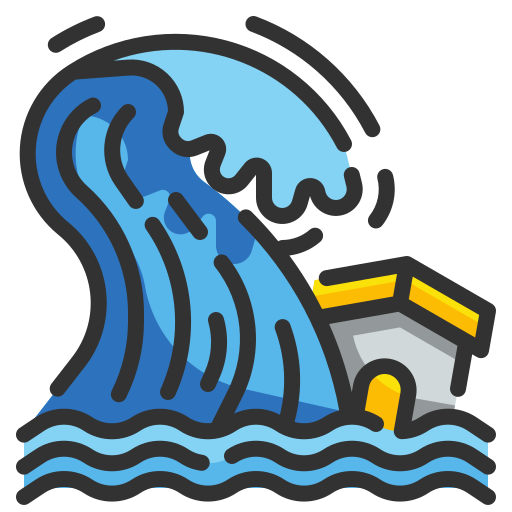
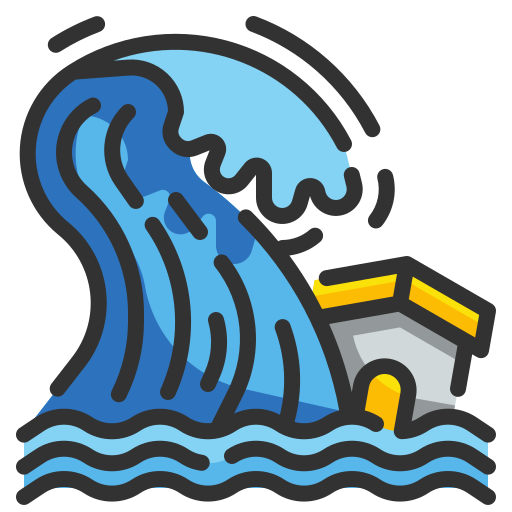

In [8]:
# Create a base map centered on Indonesia
m = folium.Map(location=[-2.5, 118.0], zoom_start=5)

# Function to assign color based on focal depth
def get_color(focal_depth):
    if focal_depth < 70:
        return 'green'
    elif focal_depth < 300:
        return 'orange'
    else:
        return 'red'

# Function to scale magnitude to marker size
def scale_magnitude(mag):
    # Adjust the scale factor, for example, multiply the magnitude by 5
    return (mag - 5) * 5  # Scaling magnitude to make a visible difference

# Add CircleMarkers for each earthquake
for _, row in eq_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=scale_magnitude(row["magnitude"]),  # Scaled marker size based on magnitude
        color=get_color(row["focal_depth"]),  # Color based on focal depth
        fill=True,
        fill_color=get_color(row["focal_depth"]),
        fill_opacity=0.6,
        popup=f"Earthquake<br>Magnitude: {row['magnitude']}<br>Focal Depth: {row['focal_depth']} km",
    ).add_to(m)

    
volcano_icon_path = "/Users/yashwanthp/Downloads/volcano.png"  # Replace with your local path

volcano_icon_url = "https://upload.wikimedia.org/wikipedia/commons/e/e6/Volcano_icon.svg"  # Volcano icon URL
for _, row in volcano_df.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        icon=folium.CustomIcon(volcano_icon_path, icon_size=(30, 30)),
        popup=f"Volcano<br>{row['name']}",
    ).add_to(m)

tsunami_icon_path = "/Users/yashwanthp/Downloads/tsunami.png"

# Add tsunamis with a local tsunami icon
for _, row in tsunami_df.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        icon=folium.CustomIcon(tsunami_icon_path, icon_size=(30, 30)),
        popup=f"Tsunami<br>Location: {row['location name']}<br>Earthquake Mag: {row['earthquake magnitude']}",
    ).add_to(m)

# Save the map as an HTML file
m.save("indonesia_combined_map.html")

# To display in Jupyter Notebook (optional)
# from IPython.display import display
display(m)

In [9]:
map = folium.Map(location=[-2.5, 118.0], zoom_start=5)
heatmap_data = []

# Earthquakes
heatmap_data.extend(eq_df[["latitude", "longitude"]].dropna().values.tolist())

# Volcanoes
heatmap_data.extend(volcano_df[["latitude", "longitude"]].dropna().values.tolist())

# Tsunamis
heatmap_data.extend(tsunami_df[["latitude", "longitude"]].dropna().values.tolist())

# Add HeatMap layer
HeatMap(heatmap_data, radius=10, blur=15, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(map)

display(map)

Earthquake size - Magnitude <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Earthquakes with focal depth greater than 70kms <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Earthquakes with focal depth between 70 kms - 300kms <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Volcano <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Tsunami